# Ch.00 Overview — Microstructure Noise / TSRV

Pass 2.6 signal board for desk readers. Empirics live in sibling chapter notebooks; this page is the map.


In [1]:
from pathlib import Path
import os
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = (Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # ares-microstructure root

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
ep = jload('expand_panel/expand_panel.json')
dp = jload('depth_predict/depth_predict.json') if (OUT/'depth_predict'/'depth_predict.json').exists() else {}
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))
print('expand n_ok', ep['coverage']['n_ok'], 'depth keys', list(dp.keys())[:8])


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_info_heatmap.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_acf_lag1.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_pred_board.png', 'fig_pred_ic_noise.png', 'fig_ratio_hist.png', 'fig_signature.png', 'fig_tob_coverage.png', 'fig_tod_acf.png', 'fig_tsrv_oos.png', 'fig_venue_mid_taxonomy.png', 'signal_board.png']
expand n_ok 204 depth keys ['meta', 'information', 'predictive', 'taxonomy', 'tape_depth', 'uses', 'figures', 'decisions_rollup']


## Signal board


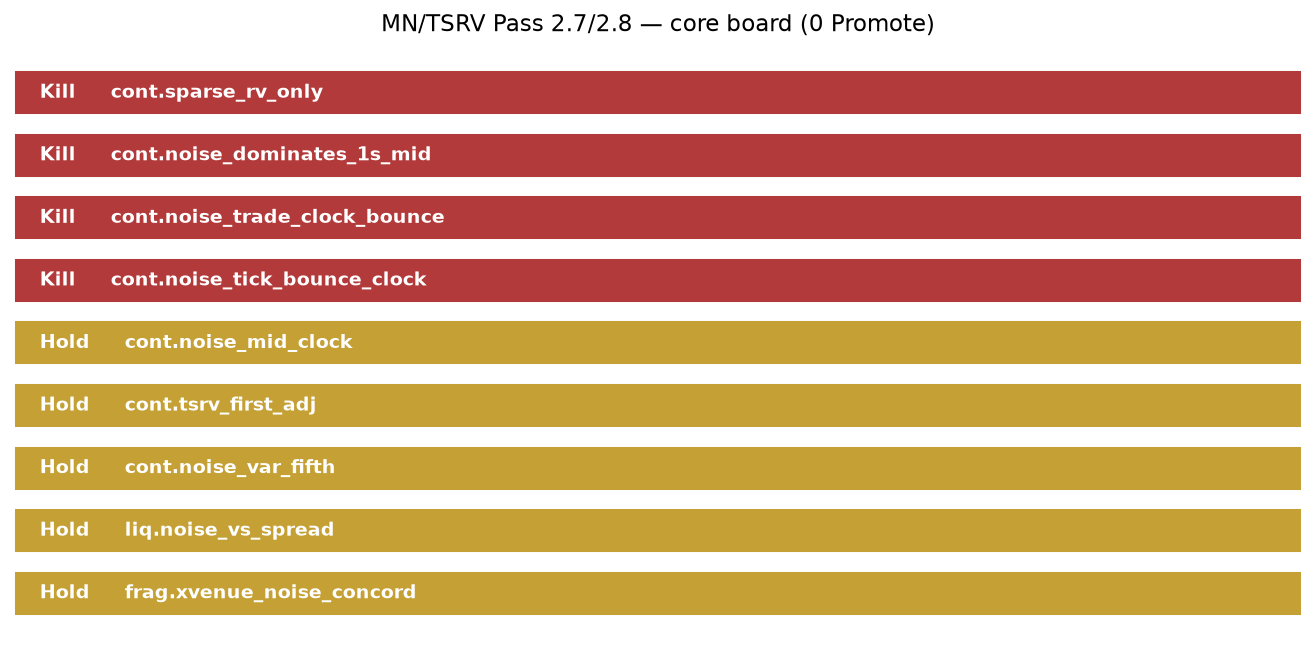

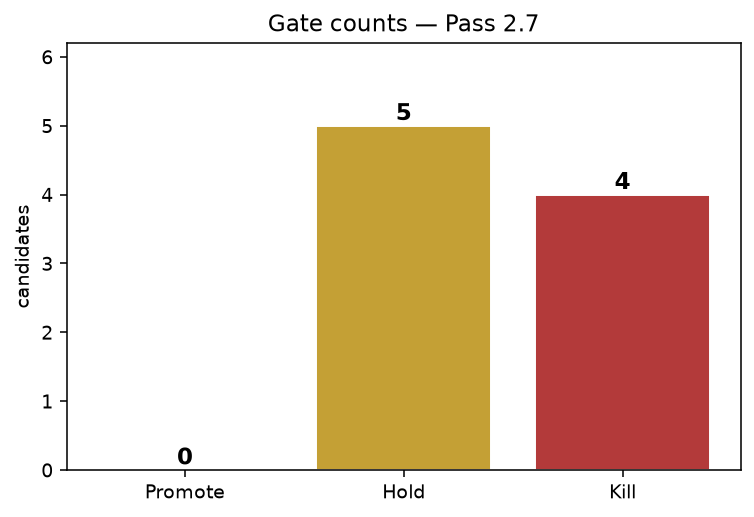

# Desk memo — Microstructure Noise / TSRV (Romero 2016 · ZMA05)

**Audience:** crypto MM / SOR / execution / taker / risk / research  
**Source:** Romero MA thesis (2016) / ZMA05 TSRV → `research/books/mn_tuwrv/`  
**Data:** warehouse trades + collector/warehouse TOB + Kraken spot L2 + futures REST ingest — **no ClickHouse MCP**  
**Program status:** **Pass 2.8 depth/predict** — **0 Promote** (Pass 2.7 board unchanged; predictive 0 Promote after encompassing) · MC **Kill** sparse stands  
**SoT:** [`CHAPTER_INDEX.md`](CHAPTER_INDEX.md) · Uses: [`TRADING_APPLICATIONS.md`](TRADING_APPLICATIONS.md) · Lib: [`../../lib/tsrv.py`](../../lib/tsrv.py)  
**Artifacts:** [`out/expand_panel/`](out/expand_panel/) · [`out/depth_predict/`](out/depth_predict/) · [`out/blocker_close/`](out/blocker_close/)  
**Desk notebooks:** [`notebooks/desk_synthesis.ipynb`](notebooks/desk_synthesis.ipynb) · [`notebooks/uses_and_information.ipynb`](notebooks/uses_and_information.ipynb) · [`notebooks/predictive_power.

In [2]:
show_fig('signal_board.png')
show_fig('fig_gate_counts.png')
print((BOOK/'DESK_MEMO.md').read_text()[:1800])


## Pre-registered gates


In [3]:
print(json.dumps(bc['meta'].get('gates'), indent=2))
print('blocker decisions:', json.dumps(bc['decisions'], indent=2)[:1500])


{
  "cont.noise_mid_clock": "CI_lo(fifth/fourth)>1.5",
  "cont.tsrv_first_adj": "fragile_rate=0 & sparse\u2212tsrv CI_lo>0 early\u2227late & n\u226520",
  "liq.noise_vs_spread": "\u03c1>0 & shuffle_p<0.05 & early\u2227late same sign & n\u226520 & CI_lo>0"
}
blocker decisions: {
  "cont.noise_mid_clock": {
    "id": "cont.noise_mid_clock",
    "decision": "Hold",
    "why": "dense mid median=2.449 CI=[1.130,3.777] SE=0.693 n=122.0 (need CI_lo>1.5)"
  },
  "cont.tsrv_first_adj": {
    "id": "cont.tsrv_first_adj",
    "decision": "Hold",
    "why": "fragile_rate=0.015 adv_med=5.58e-07 CI=[-5.949090895340435e-07, 3.4256954437953243e-06] SE=9.82e-07 earlyCI=[1.446921174782248e-07, 1.1235763937995365e-05] lateCI=[-2.9783714540724274e-06, 1.382499195019151e-06] ratio_med=0.9844 ratioCI=[0.9628826697099598, 1.0109329144617558] roll_ci_lo_pos_frac=0.07 n=204 (MC Kill sparse still stands; Promote needs OOS CI_lo>0 early\u2227late)"
  },
  "cont.sparse_rv_only": {
    "decision": "Kill",
    "why